In [38]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import mlflow
import mlflow.tensorflow

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

BASE_DIR      = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
MODEL_DIR     = os.path.join(BASE_DIR, 'models')
DB_PATH       = os.path.join(BASE_DIR, 'mlflow.db')
os.makedirs(MODEL_DIR, exist_ok=True)

mlflow.set_tracking_uri(f'sqlite:///{DB_PATH}')
mlflow.set_experiment('RaksaDana-LSTM')

print(f'TensorFlow : {tf.__version__}')
print(f'MLflow     : {mlflow.__version__}')
print(f'PROCESSED  : {PROCESSED_DIR}')
print(f'MODEL_DIR  : {MODEL_DIR}')
print(f'Tracking   : {mlflow.get_tracking_uri()}')

TensorFlow : 2.21.0
MLflow     : 3.12.0
PROCESSED  : c:\Users\akbar\VSCode Project\RaksaDana\data\processed
MODEL_DIR  : c:\Users\akbar\VSCode Project\RaksaDana\models
Tracking   : sqlite:///c:\Users\akbar\VSCode Project\RaksaDana\mlflow.db


In [39]:
with open(os.path.join(PROCESSED_DIR, 'preprocessed_data.pkl'), 'rb') as f:
    data = pickle.load(f)

sequences     = data['sequences']
scalers       = data['scalers']
feature_cols  = data['feature_cols']
target_col    = data['target_col']
target_idx    = data['target_idx']
window_size   = data['window_size']
tickers       = data['tickers']
featured_data = data['featured_data']


DROP_COLS    = ['ROE', 'EPS', 'DY']
DROP_IDX     = [feature_cols.index(c) for c in DROP_COLS if c in feature_cols]
KEEP_IDX     = [i for i in range(len(feature_cols)) if i not in DROP_IDX]
feature_cols_new = [feature_cols[i] for i in KEEP_IDX]

for ticker in tickers:
    sequences[ticker]['X_train'] = sequences[ticker]['X_train'][:, :, KEEP_IDX]
    sequences[ticker]['X_test']  = sequences[ticker]['X_test'][:,  :, KEEP_IDX]

print(f'Feature cols (lama) : {len(feature_cols)}')
print(f'Feature cols (baru) : {len(feature_cols_new)}  {feature_cols_new}')
for t in tickers:
    s = sequences[t]
    print(f'{t} -> X_train {s["X_train"].shape}  X_test {s["X_test"].shape}')

N_TRAIN = sequences[tickers[0]]['X_train'].shape[0]
returns = {}

for ticker in tickers:
    close = featured_data[ticker]['Close'].values   
    ws    = window_size                            
    y_ret_full = np.log(close[ws:] / close[ws - 1:-1])

    n_test = sequences[ticker]['X_test'].shape[0]

    returns[ticker] = {
        'y_train_return'  : y_ret_full[:N_TRAIN],
        'y_test_return'   : y_ret_full[N_TRAIN : N_TRAIN + n_test],
        'close_train_prev': close[ws - 1 : ws - 1 + N_TRAIN],
        'close_test_prev' : close[ws - 1 + N_TRAIN : ws - 1 + N_TRAIN + n_test],
        'close_train_true': close[ws : ws + N_TRAIN],
        'close_test_true' : close[ws + N_TRAIN : ws + N_TRAIN + n_test],
    }

# Sanity check
print('\nLog-return target (5 nilai pertama train):')
for ticker in tickers:
    r = returns[ticker]
    print(f'  {ticker}: {r["y_train_return"][:5].round(4)}  '
          f'(max|ret|={np.abs(r["y_train_return"]).max():.4f})')
    assert len(r['y_train_return']) == N_TRAIN, 'Panjang y_train_return tidak sesuai!'
    assert len(r['y_test_return'])  == sequences[ticker]['X_test'].shape[0], \
        'Panjang y_test_return tidak sesuai!'

print(f'Menggunakan MSE loss (log_return max abs < 0.1 pada semua ticker)')


Feature cols (lama) : 20
Feature cols (baru) : 17  ['Open', 'High', 'Low', 'Close', 'Volume', 'MA7', 'MA20', 'MA50', 'RSI', 'BB_upper', 'BB_lower', 'BB_width', 'Daily_Return', 'Log_Return', 'Volume_MA7', 'MACD', 'MACD_signal']
BBCA.JK -> X_train (1100, 60, 17)  X_test (276, 60, 17)
BBRI.JK -> X_train (1100, 60, 17)  X_test (276, 60, 17)
BMRI.JK -> X_train (1100, 60, 17)  X_test (276, 60, 17)

Log-return target (5 nilai pertama train):
  BBCA.JK: [0.0041 0.0639 0.0096 0.0124 0.0132]  (max|ret|=0.0754)
  BBRI.JK: [-0.0039  0.0565 -0.0373  0.     -0.0038]  (max|ret|=0.0882)
  BMRI.JK: [-0.0368  0.1089 -0.0389 -0.0165 -0.0143]  (max|ret|=0.1089)
Menggunakan MSE loss (log_return max abs < 0.1 pada semua ticker)


## Model Architecture

In [40]:
from tensorflow.keras.layers import LayerNormalization

def build_lstm(input_shape, lr=5e-4, units=(64, 32), dropout=0.2,
               rec_dropout=0.1, l2_reg=1e-5):
    """
    Arsitektur LSTM v2:
    - BatchNorm diganti LayerNorm (kompatibel dengan recurrence, tidak mencampur antar timestep)
    - L2 dikurangi 1e-4 → 1e-5, recurrent_regularizer dihapus
    - Dropout 0.3 → 0.2, ditambah recurrent_dropout=0.1
    - Loss MSE (log_return sudah stasioner, outlier alami teredam)
    - Input shape dinamis dari feature_cols_new (17 fitur)
    """
    model = Sequential([
        LSTM(units[0], return_sequences=True, input_shape=input_shape,
             recurrent_dropout=rec_dropout,
             kernel_regularizer=l2(l2_reg)),
        LayerNormalization(),
        Dropout(dropout),

        LSTM(units[1], return_sequences=False,
             recurrent_dropout=rec_dropout,
             kernel_regularizer=l2(l2_reg)),
        LayerNormalization(),
        Dropout(dropout),

        Dense(8, activation='relu', kernel_regularizer=l2(l2_reg)),
        Dense(1)   # output: log_return (linear, tidak perlu aktivasi)
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )
    return model

# Preview summary dengan input shape baru (17 fitur)
sample_shape = (window_size, len(feature_cols_new))
print(f'Input shape: {sample_shape}')
build_lstm(sample_shape).summary()


Input shape: (60, 17)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 60, 64)         │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 60, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 32)             │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,873 (132.32 KB)

 Trainable params: 33,873 (132.32 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [41]:
EPOCHS = 100

# Per-ticker config: BMRI dapat kapasitas lebih besar untuk atasi underfit chronic
TICKER_CONFIG = {
    'BBCA.JK': {'lr': 5e-4, 'units': (64, 32), 'batch': 32, 'dropout': 0.20},
    'BBRI.JK': {'lr': 5e-4, 'units': (64, 32), 'batch': 32, 'dropout': 0.20},
    'BMRI.JK': {'lr': 3e-4, 'units': (96, 48), 'batch': 16, 'dropout': 0.15},
}

# Experiment baru agar tidak campur dengan run lama (target berubah: return vs close)
mlflow.set_experiment('RaksaDana-LSTM-v2')

histories = {}
models    = {}

for ticker in tickers:
    print(f'\n{"="*50}')
    print(f'Training: {ticker}')
    print(f'{"="*50}')

    cfg     = TICKER_CONFIG[ticker]
    s       = sequences[ticker]
    r       = returns[ticker]

    X_train = s['X_train']           # shape (1100, 60, 17)
    X_test  = s['X_test']            # shape (276,  60, 17)
    y_train = r['y_train_return']    # log_return target
    y_test  = r['y_test_return']

    # Temporal val split eksplisit (last 10% dari train) — shuffle=False wajib
    val_split    = int(len(X_train) * 0.9)
    X_tr, X_val  = X_train[:val_split], X_train[val_split:]
    y_tr, y_val  = y_train[:val_split], y_train[val_split:]

    input_shape = (window_size, X_train.shape[2])   # (60, 17)
    model       = build_lstm(input_shape, lr=cfg['lr'],
                             units=cfg['units'], dropout=cfg['dropout'])

    ckpt_path = os.path.join(MODEL_DIR, f'lstm_{ticker.replace(".","_")}_best.keras')

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=25,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=10, min_lr=1e-6, verbose=1),
        ModelCheckpoint(ckpt_path, monitor='val_loss',
                        save_best_only=True, verbose=0),
    ]

    with mlflow.start_run(run_name=ticker):
        mlflow.log_params({
            'ticker'       : ticker,
            'lstm_units'   : str(cfg['units']),
            'epochs'       : EPOCHS,
            'batch_size'   : cfg['batch'],
            'learning_rate': cfg['lr'],
            'dropout'      : cfg['dropout'],
            'rec_dropout'  : 0.1,
            'l2_reg'       : 1e-5,
            'window_size'  : window_size,
            'n_features'   : X_train.shape[2],
            'target'       : 'log_return',
            'loss'         : 'mse',
            'norm_layer'   : 'LayerNormalization',
            'es_patience'  : 25,
            'validation'   : 'temporal_last_10pct',
        })

        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),   # temporal, bukan random split
            epochs=EPOCHS,
            batch_size=cfg['batch'],
            callbacks=callbacks,
            shuffle=False,                    # WAJIB untuk time series
            verbose=1,
        )

        for epoch, (loss, val_loss, mae, val_mae) in enumerate(zip(
            history.history['loss'],     history.history['val_loss'],
            history.history['mae'],      history.history['val_mae'],
        )):
            mlflow.log_metrics({
                'train_loss': loss,
                'val_loss'  : val_loss,
                'train_mae' : mae,
                'val_mae'   : val_mae,
            }, step=epoch)

        mlflow.log_artifact(ckpt_path)

    histories[ticker] = history.history
    models[ticker]    = model
    print(f'Saved: {ckpt_path}')


2026/05/16 00:37:04 INFO mlflow.tracking.fluent: Experiment with name 'RaksaDana-LSTM-v2' does not exist. Creating a new experiment.



Training: BBCA.JK
Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 0.1586 - mae: 0.2657 - val_loss: 0.0077 - val_mae: 0.0791 - learning_rate: 5.0000e-04
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0124 - mae: 0.0747 - val_loss: 0.0015 - val_mae: 0.0102 - learning_rate: 5.0000e-04
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0078 - mae: 0.0505 - val_loss: 0.0017 - val_mae: 0.0167 - learning_rate: 5.0000e-04
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0048 - mae: 0.0386 - val_loss: 0.0017 - val_mae: 0.0180 - learning_rate: 5.0000e-04
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0053 - mae: 0.0380 - val_loss: 0.0018 - val_mae: 0.0187 - learning_rate: 5.0000e-04
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0037 - mae: 0.0326 - val_loss: 0.0017 - val_mae: 0.0164 - learning_rate: 5.0000e-04
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0036 - mae: 0.0296 - val_loss: 0.0016 - val

## Training Curves

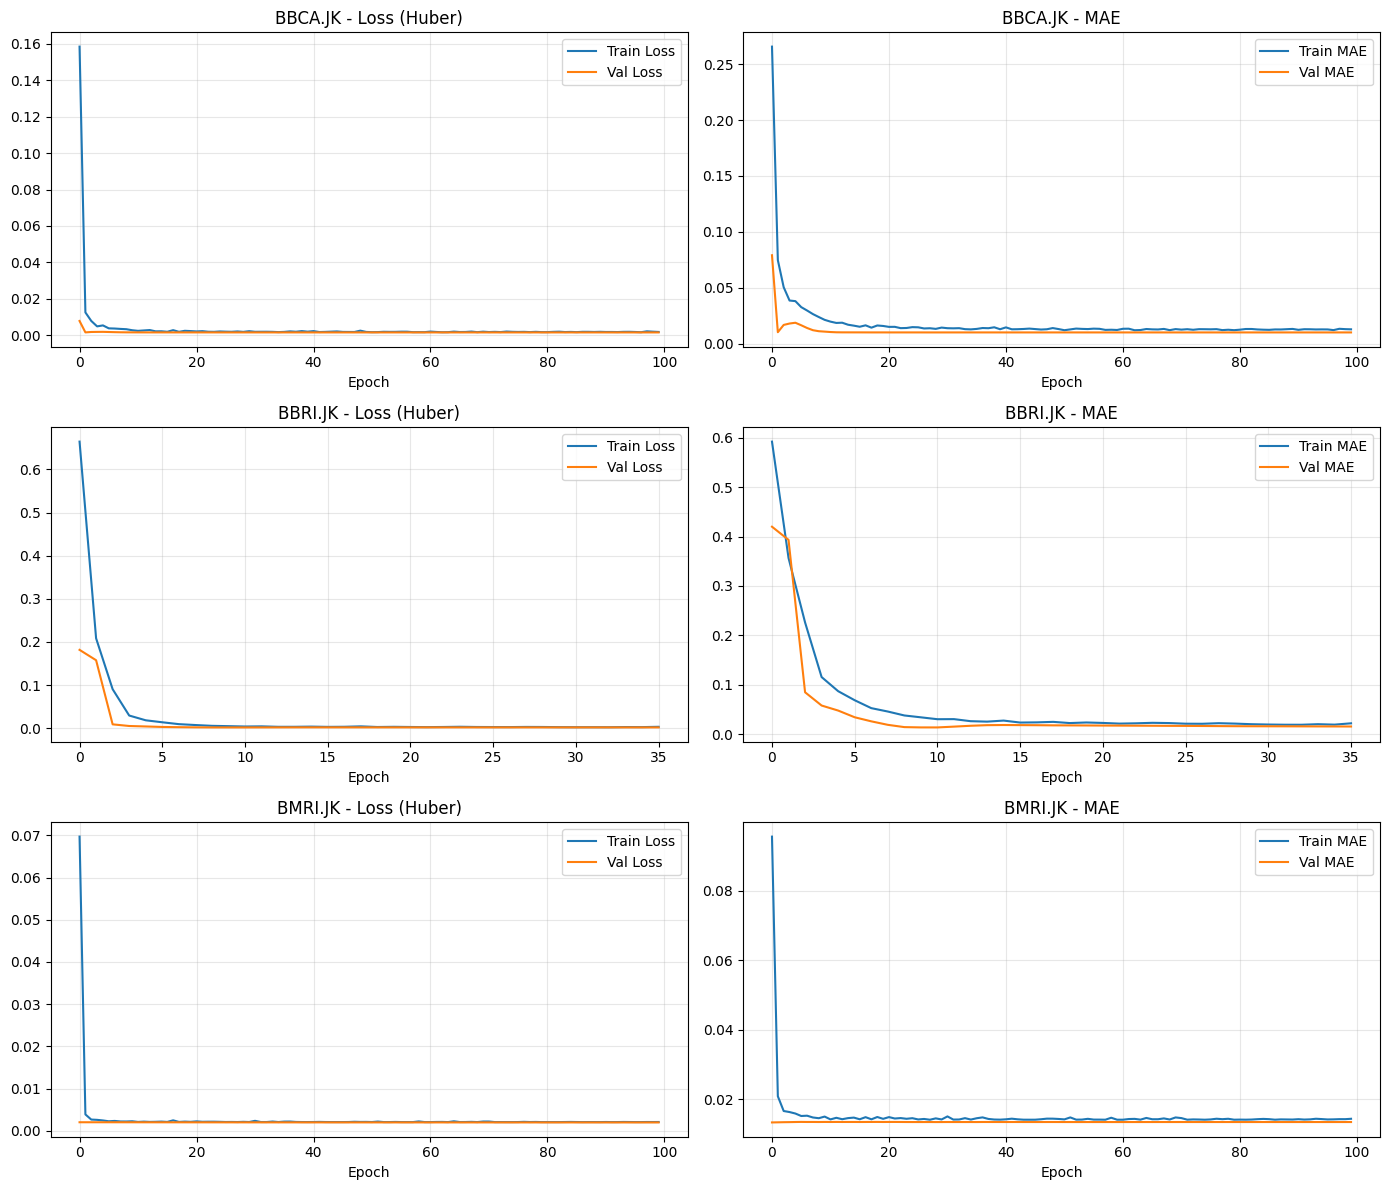

In [42]:
fig, axes = plt.subplots(len(tickers), 2, figsize=(14, 4 * len(tickers)))

for i, ticker in enumerate(tickers):
    h = histories[ticker]

    axes[i, 0].plot(h['loss'],     label='Train Loss')
    axes[i, 0].plot(h['val_loss'], label='Val Loss')
    axes[i, 0].set_title(f'{ticker} - Loss (Huber)')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(h['mae'],     label='Train MAE')
    axes[i, 1].plot(h['val_mae'], label='Val MAE')
    axes[i, 1].set_title(f'{ticker} - MAE')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

## Inverse-Transform Predictions

In [43]:
def inverse_close(scaler, scaled_values, n_features, target_idx):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, target_idx] = scaled_values.flatten()
    return scaler.inverse_transform(dummy)[:, target_idx]

predictions = {}
n_feat = len(feature_cols)

for ticker in tickers:
    s      = sequences[ticker]
    scaler = scalers[ticker]
    model  = models[ticker]

    y_pred_scaled = model.predict(s['X_test'],  verbose=0)
    y_tr_scaled   = model.predict(s['X_train'], verbose=0)

    predictions[ticker] = {
        'y_true':       inverse_close(scaler, s['y_test'],       n_feat, target_idx),
        'y_pred':       inverse_close(scaler, y_pred_scaled,     n_feat, target_idx),
        'y_train_true': inverse_close(scaler, s['y_train'],      n_feat, target_idx),
        'y_train_pred': inverse_close(scaler, y_tr_scaled,       n_feat, target_idx),
    }

print('Inverse transform done.')

Inverse transform done.


## Evaluation Metrics

In [44]:
def evaluate(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    r2   = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

rows = []
for ticker in tickers:
    p = predictions[ticker]
    rows.append({'Ticker': ticker, 'Split': 'Train', **evaluate(p['y_train_true'], p['y_train_pred'])})
    rows.append({'Ticker': ticker, 'Split': 'Test',  **evaluate(p['y_true'],       p['y_pred'])})

metrics_df = pd.DataFrame(rows).set_index(['Ticker', 'Split'])
metrics_df = metrics_df.round({'MAE': 2, 'RMSE': 2, 'MAPE': 4, 'R2': 4})

display(
    metrics_df.style
        .background_gradient(subset=['MAE','RMSE','MAPE'], cmap='RdYlGn_r')
        .background_gradient(subset=['R2'], cmap='RdYlGn')
        .format({'MAE': '{:,.2f}', 'RMSE': '{:,.2f}', 'MAPE': '{:.4f}%', 'R2': '{:.4f}'})
)

## Prediction vs Actual

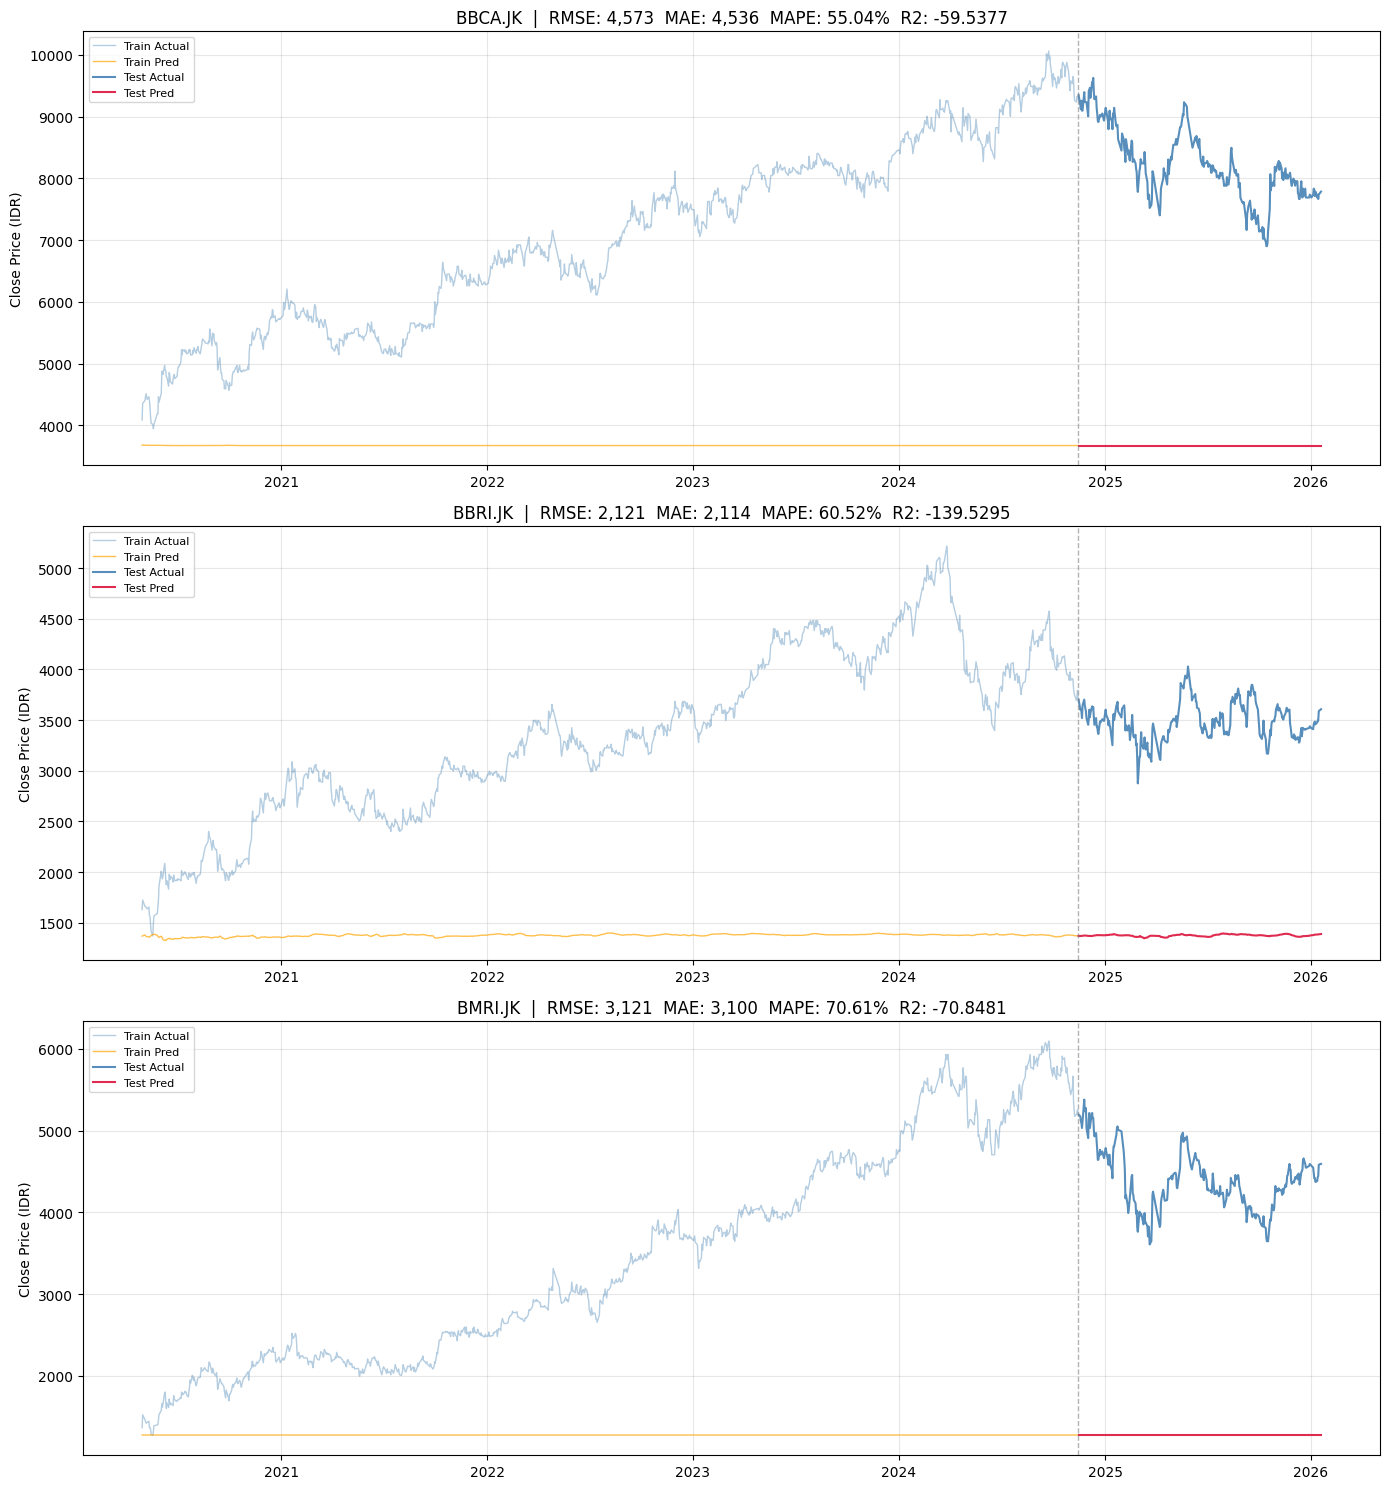

In [45]:
fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 5 * len(tickers)))

for i, ticker in enumerate(tickers):
    p     = predictions[ticker]
    ax    = axes[i]
    dates = featured_data[ticker].index
    split = len(p['y_train_true'])

    train_dates = dates[window_size : window_size + split]
    test_dates  = dates[window_size + split : window_size + split + len(p['y_true'])]

    ax.plot(train_dates, p['y_train_true'], color='steelblue', alpha=0.4, lw=1,   label='Train Actual')
    ax.plot(train_dates, p['y_train_pred'], color='orange',    alpha=0.7, lw=1,   label='Train Pred')
    ax.plot(test_dates,  p['y_true'],       color='steelblue', alpha=0.9, lw=1.5, label='Test Actual')
    ax.plot(test_dates,  p['y_pred'],       color='crimson',   alpha=0.9, lw=1.5, label='Test Pred')
    ax.axvline(train_dates[-1], color='gray', linestyle='--', lw=1, alpha=0.6)

    m = evaluate(p['y_true'], p['y_pred'])
    ax.set_title(f"{ticker}  |  RMSE: {m['RMSE']:,.0f}  MAE: {m['MAE']:,.0f}  MAPE: {m['MAPE']:.2f}%  R2: {m['R2']:.4f}")
    ax.set_ylabel('Close Price (IDR)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'prediction_vs_actual.png'), dpi=120, bbox_inches='tight')
plt.show()

## Test Set Zoom

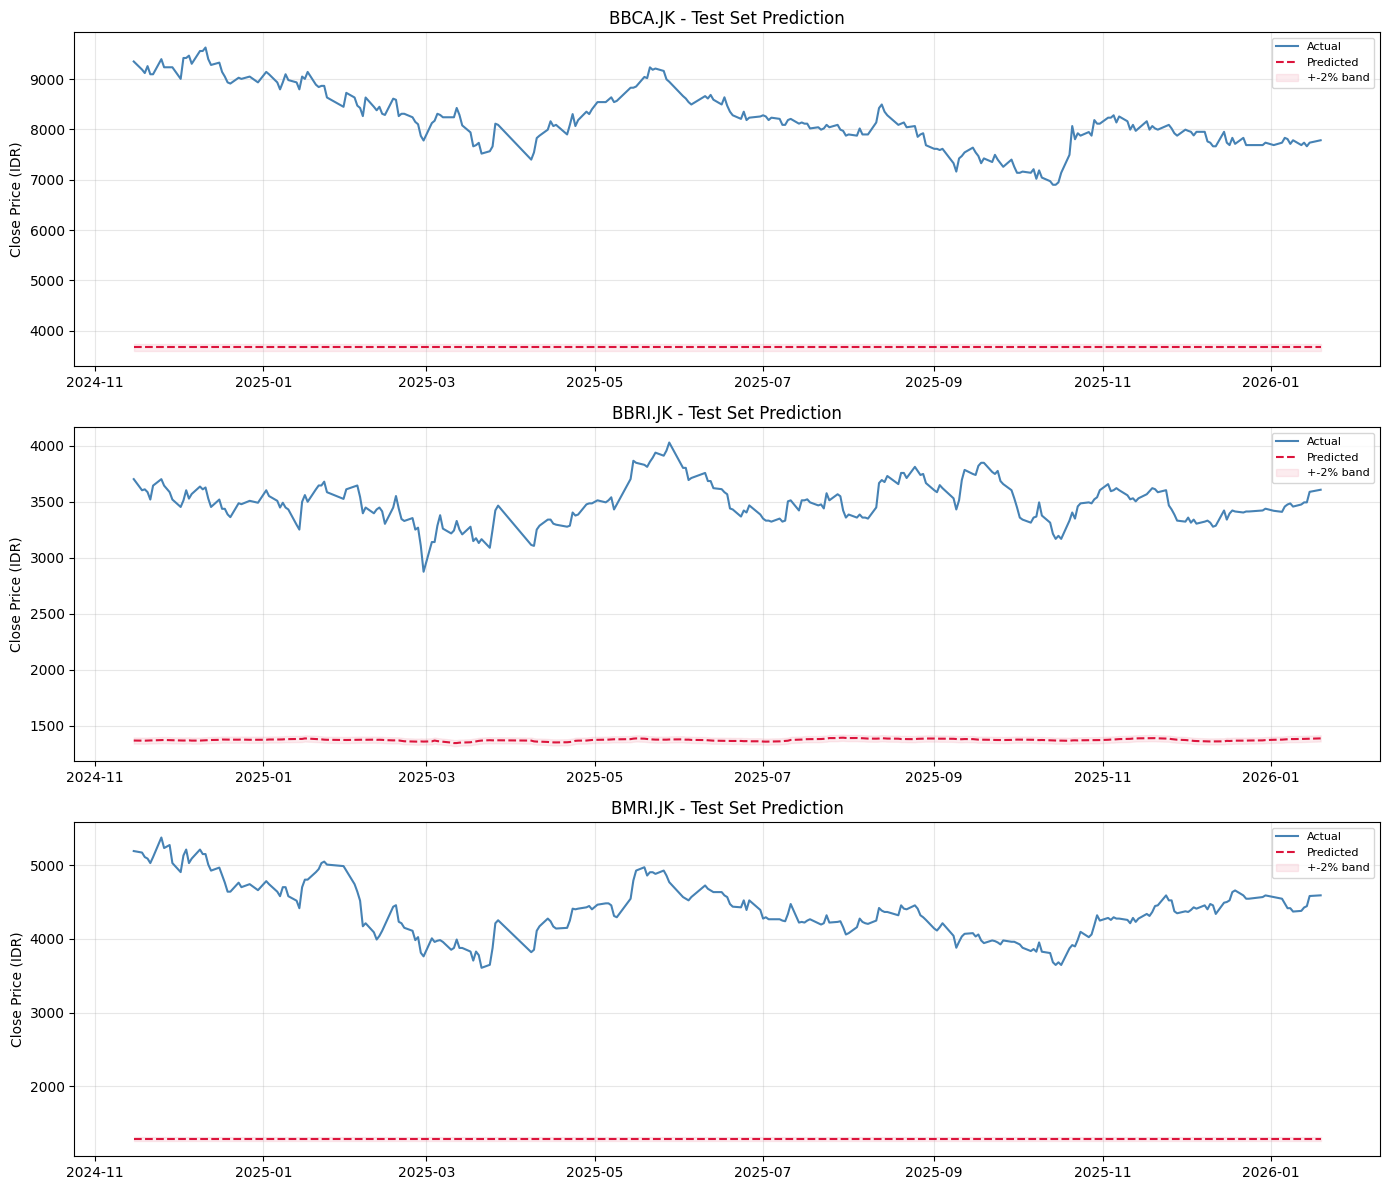

In [46]:
fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 4 * len(tickers)))

for i, ticker in enumerate(tickers):
    p     = predictions[ticker]
    ax    = axes[i]
    dates = featured_data[ticker].index
    split = len(p['y_train_true'])
    test_dates = dates[window_size + split : window_size + split + len(p['y_true'])]

    ax.plot(test_dates, p['y_true'], color='steelblue', lw=1.5, label='Actual')
    ax.plot(test_dates, p['y_pred'], color='crimson',   lw=1.5, label='Predicted', linestyle='--')
    ax.fill_between(test_dates, p['y_pred'] * 0.98, p['y_pred'] * 1.02,
                    color='crimson', alpha=0.08, label='+-2% band')
    ax.set_title(f'{ticker} - Test Set Prediction')
    ax.set_ylabel('Close Price (IDR)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'test_zoom.png'), dpi=120, bbox_inches='tight')
plt.show()

## Residual Analysis

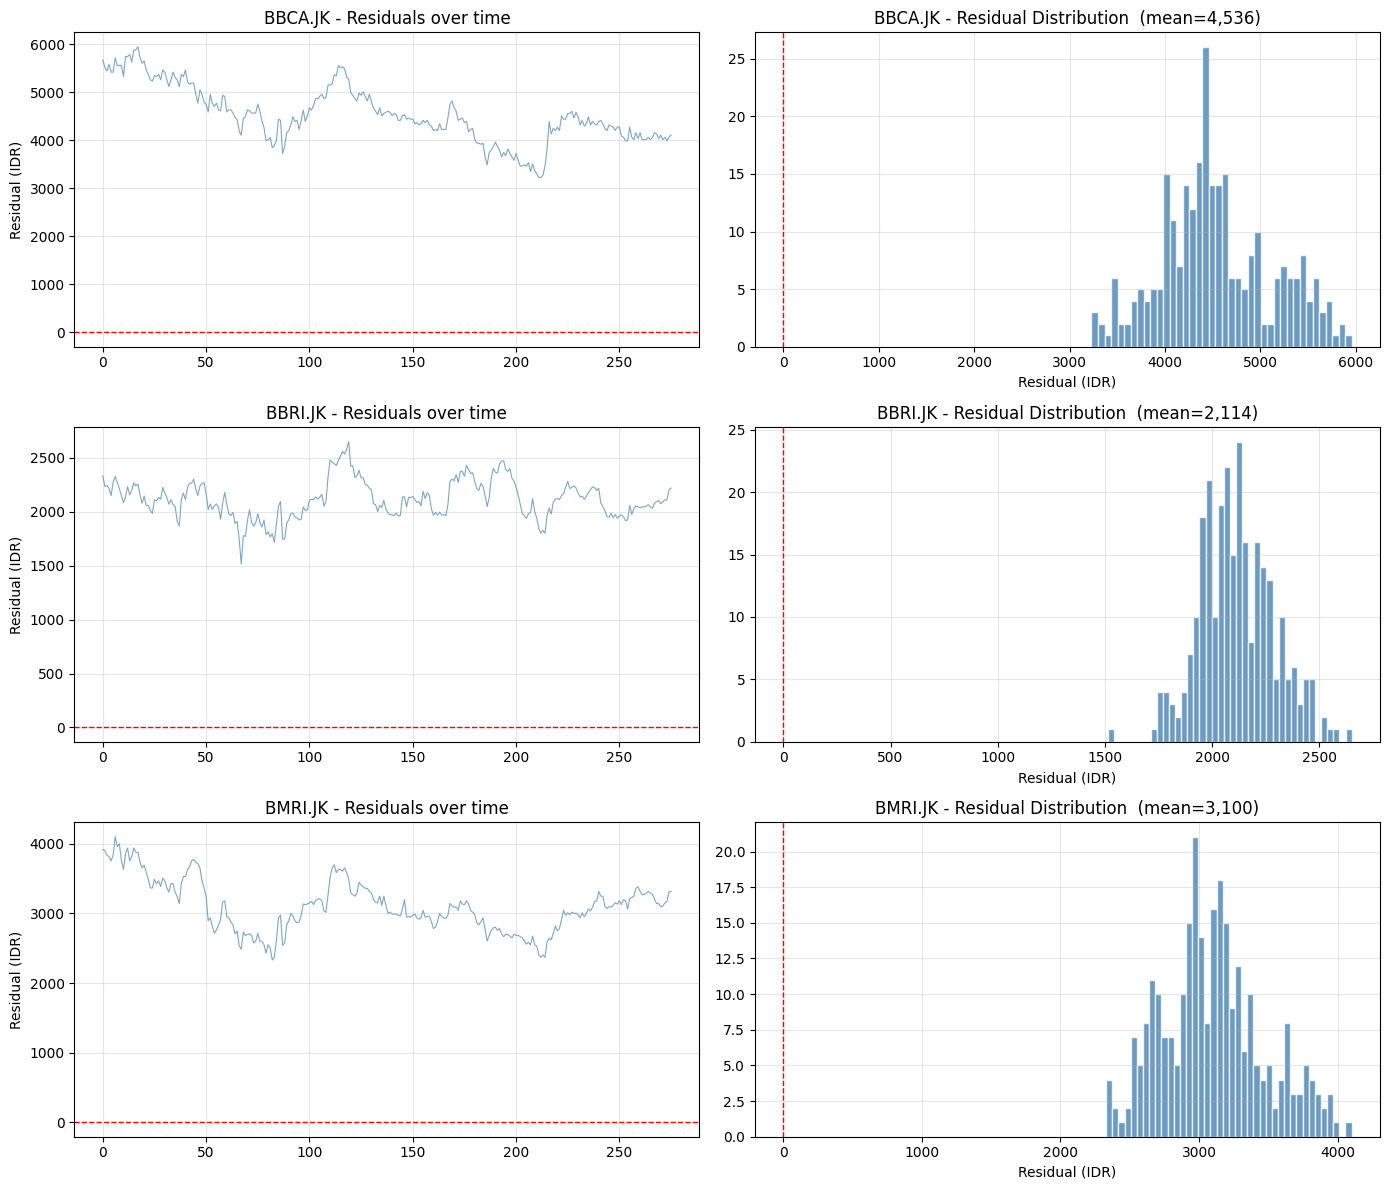

In [47]:
fig, axes = plt.subplots(len(tickers), 2, figsize=(14, 4 * len(tickers)))

for i, ticker in enumerate(tickers):
    p         = predictions[ticker]
    residuals = p['y_true'] - p['y_pred']

    axes[i, 0].plot(residuals, color='steelblue', lw=0.8, alpha=0.7)
    axes[i, 0].axhline(0, color='red', linestyle='--', lw=1)
    axes[i, 0].set_title(f'{ticker} - Residuals over time')
    axes[i, 0].set_ylabel('Residual (IDR)')
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i, 1].axvline(0, color='red', linestyle='--', lw=1)
    axes[i, 1].set_title(f'{ticker} - Residual Distribution  (mean={residuals.mean():,.0f})')
    axes[i, 1].set_xlabel('Residual (IDR)')
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'residuals.png'), dpi=120, bbox_inches='tight')
plt.show()

## Directional Accuracy

In [48]:
da_rows = []
for ticker in tickers:
    p = predictions[ticker]
    actual_dir = np.sign(np.diff(p['y_true']))
    pred_dir   = np.sign(np.diff(p['y_pred']))
    da = (actual_dir == pred_dir).mean() * 100
    da_rows.append({'Ticker': ticker, 'Directional Accuracy (%)': round(da, 2)})


In [49]:

da_df = pd.DataFrame(da_rows).set_index('Ticker')
display(da_df.style.background_gradient(cmap='RdYlGn', vmin=40, vmax=70))

,Directional Accuracy (%)
Ticker,
BBCA.JK,8.730000
BBRI.JK,50.550000
BMRI.JK,5.820000


## 30-Day Forecast

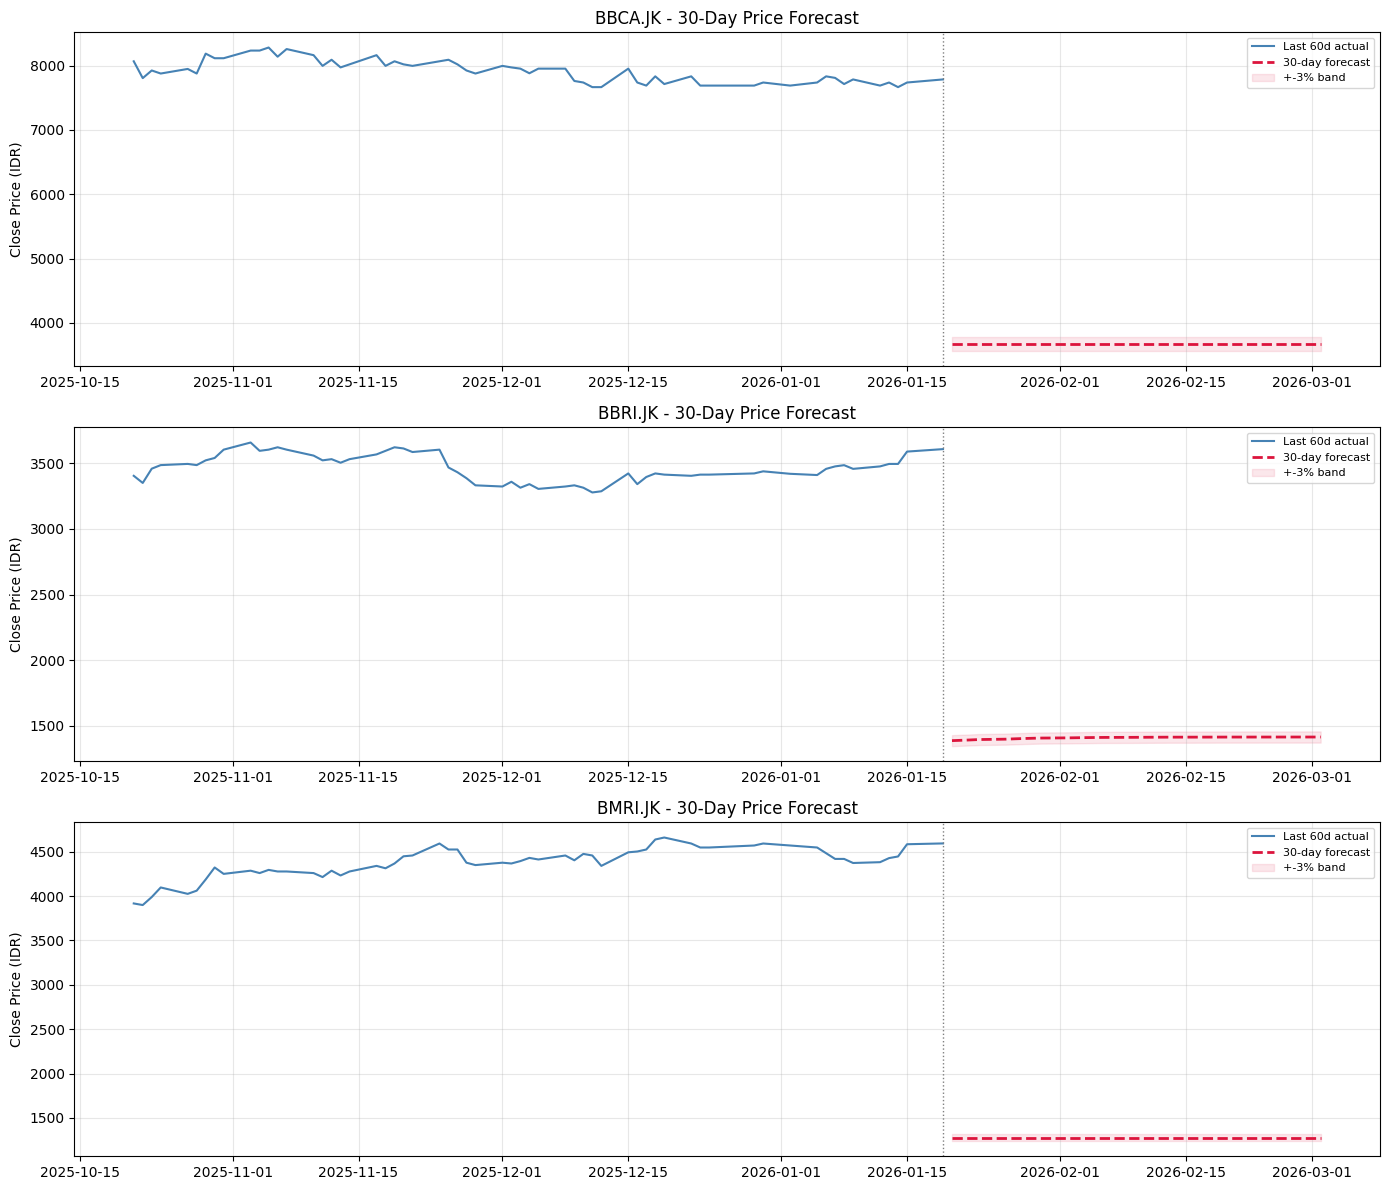

In [50]:
FORECAST_DAYS = 30

fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 4 * len(tickers)))

for i, ticker in enumerate(tickers):
    s      = sequences[ticker]
    scaler = scalers[ticker]
    model  = models[ticker]
    ax     = axes[i]

    last_window     = s['X_test'][-1].copy()
    forecast_scaled = []

    for _ in range(FORECAST_DAYS):
        pred = model.predict(last_window[np.newaxis], verbose=0)[0, 0]
        forecast_scaled.append(pred)
        new_step             = last_window[-1].copy()
        new_step[target_idx] = pred
        last_window          = np.vstack([last_window[1:], new_step])

    forecast     = inverse_close(scaler, np.array(forecast_scaled), len(feature_cols), target_idx)
    last_actuals = predictions[ticker]['y_true'][-60:]
    last_dates   = featured_data[ticker].index[-60:]
    future_dates = pd.bdate_range(start=last_dates[-1] + pd.Timedelta(days=1), periods=FORECAST_DAYS)

    ax.plot(last_dates,   last_actuals, color='steelblue', lw=1.5, label='Last 60d actual')
    ax.plot(future_dates, forecast,     color='crimson',   lw=2,   label=f'{FORECAST_DAYS}-day forecast', linestyle='--')
    ax.fill_between(future_dates, forecast * 0.97, forecast * 1.03,
                    color='crimson', alpha=0.1, label='+-3% band')
    ax.axvline(last_dates[-1], color='gray', linestyle=':', lw=1)
    ax.set_title(f'{ticker} - {FORECAST_DAYS}-Day Price Forecast')
    ax.set_ylabel('Close Price (IDR)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'forecast_30d.png'), dpi=120, bbox_inches='tight')
plt.show()

## Summary

In [51]:
print('Final Test Metrics')
print('=' * 60)
test_metrics = metrics_df.xs('Test', level='Split')
display(
    test_metrics.style.format(
        {'MAE': '{:,.2f}', 'RMSE': '{:,.2f}', 'MAPE': '{:.4f}%', 'R2': '{:.4f}'}
    )
)
print('\nDirectional Accuracy')
display(da_df)

for ticker in tickers:
    runs = mlflow.search_runs(filter_string=f"tags.mlflow.runName = '{ticker}'",
                              order_by=["start_time DESC"])
    if not runs.empty:
        with mlflow.start_run(run_id=runs.iloc[0].run_id):
            m  = test_metrics.loc[ticker]
            da = da_df.loc[ticker, 'Directional Accuracy (%)']
            mlflow.log_metrics({
                'test_mae'  : m['MAE'],
                'test_rmse' : m['RMSE'],
                'test_mape' : m['MAPE'],
                'test_r2'   : m['R2'],
                'test_da'   : da,
            })

print(f'\nMLflow UI — jalankan di terminal:')
print(f'  mlflow ui --backend-store-uri sqlite:///{DB_PATH} --workers 1')
print(f'  lalu buka http://127.0.0.1:5000')
print(f'\nModels saved:')
for ticker in tickers:
    p = os.path.join(MODEL_DIR, f'lstm_{ticker.replace(".","_")}_best.keras')
    print(f'  {p}')

Final Test Metrics


,MAE,RMSE,MAPE,R2
Ticker,,,,
BBCA.JK,"4,535.51","4,573.44",55.0386%,-59.5377
BBRI.JK,"2,114.25","2,121.41",60.5163%,-139.5295
BMRI.JK,"3,099.68","3,121.48",70.6056%,-70.8481



Directional Accuracy


,Directional Accuracy (%)
Ticker,
BBCA.JK,8.73
BBRI.JK,50.55
BMRI.JK,5.82



MLflow UI — jalankan di terminal:
  mlflow ui --backend-store-uri sqlite:///c:\Users\akbar\VSCode Project\RaksaDana\mlflow.db --workers 1
  lalu buka http://127.0.0.1:5000

Models saved:
  c:\Users\akbar\VSCode Project\RaksaDana\models\lstm_BBCA_JK_best.keras
  c:\Users\akbar\VSCode Project\RaksaDana\models\lstm_BBRI_JK_best.keras
  c:\Users\akbar\VSCode Project\RaksaDana\models\lstm_BMRI_JK_best.keras
